# IndabaX Botswana Hackathon 2026
## Forecasting Botswana's Food Price Inflation Under Global Economic Shocks

### Notebook 05: HCP Linkage — Granger Causality & Regression

**Purpose:** Quantifies the relationship between Botswana's food price
inflation (`target_food_price_inflation`) and food-price CPI inflation in
comparator countries, using Granger causality tests and OLS regression —
the statistical evidence required by the HCP Linkage Memo (Criterion E).
Produces a forward projection for Jan-Dec 2024 using the team's final
submitted LSTM forecast, plus the two required HCP visualisations
(historical co-movement + forward projection).

**Input:**
- `data/processed/merged_monthly_features.csv` (Notebook 01 output — pre-lag monthly table)
- `data/processed/predictions_final_lstm.csv` (Notebook 04 output — final submitted Jan-Dec 2024 forecast)

**Output:**
- `data/processed/hcp_forward_projection_2024.csv`
- `outputs/figures/hcp_historical_comovement.png`
- `outputs/figures/hcp_forward_projection.png`

---
**Note on model choice:** the classical baseline was recently changed from
SARIMAX to XGBoost — see Notebook 03. This notebook's analysis is
model-agnostic; it uses whichever forecast is saved to
`predictions_final_lstm.csv`, which per the team's final decision is the
LSTM output.


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

merged = pd.read_csv("../data/processed/merged_monthly_features.csv")
merged["year_month"] = pd.to_datetime(merged["year_month"])
merged = merged.dropna(subset=["target_food_price_inflation"]).reset_index(drop=True)

TARGET = "target_food_price_inflation"

preds = pd.read_csv("../data/processed/predictions_final_lstm.csv")  # final submitted LSTM forecast

print("Historical data:", merged.shape, merged['year_month'].min(), "-", merged['year_month'].max())
print("\nFinal forecast (Jan-Dec 2024):")
preds


Historical data: (276, 23) 2001-01-01 00:00:00 - 2023-12-01 00:00:00

Final forecast (Jan-Dec 2024):


,year_month,forecast
0,2024-01,4.93
1,2024-02,5.23
2,2024-03,5.60
3,2024-04,3.84
4,2024-05,4.09
5,2024-06,4.54
6,2024-07,4.24
7,2024-08,3.14
8,2024-09,3.46
9,2024-10,5.28


## Step 1 — Stationarity check (ADF test)

Granger causality assumes stationary input series, so every candidate is
tested with an Augmented Dickey-Fuller test first.


In [2]:
candidates = ["hcp_zaf_fao_cp_23014", "hcp_nam_fao_cp_23014", "hcp_ken_fao_cp_23014", "hcp_zwe_fao_cp_23014"]
country_names = {"hcp_zaf_fao_cp_23014": "South Africa", "hcp_nam_fao_cp_23014": "Namibia",
                  "hcp_ken_fao_cp_23014": "Kenya", "hcp_zwe_fao_cp_23014": "Zimbabwe"}

for col in [TARGET] + candidates:
    series = merged[col].dropna()
    stat, pval, *_ = adfuller(series)
    print(f"{country_names.get(col, 'Botswana (target)'):15s} ({col}): ADF p={pval:.4f} "
          f"-> {'stationary' if pval < 0.05 else 'NOT stationary'}")


Botswana (target) (target_food_price_inflation): ADF p=0.2204 -> NOT stationary
South Africa    (hcp_zaf_fao_cp_23014): ADF p=0.0049 -> stationary
Namibia         (hcp_nam_fao_cp_23014): ADF p=0.0101 -> stationary
Kenya           (hcp_ken_fao_cp_23014): ADF p=0.0009 -> stationary
Zimbabwe        (hcp_zwe_fao_cp_23014): ADF p=0.3436 -> NOT stationary


In [3]:
# First-difference every series for a consistent, valid Granger test
diff_df = pd.DataFrame({"year_month": merged["year_month"]})
diff_df["target_diff"] = merged[TARGET].diff()
for c in candidates:
    diff_df[f"{c}_diff"] = merged[c].diff()
diff_df = diff_df.dropna().reset_index(drop=True)

for col in ["target_diff"] + [f"{c}_diff" for c in candidates]:
    stat, pval, *_ = adfuller(diff_df[col])
    print(f"{col}: ADF p={pval:.4f} -> {'stationary' if pval < 0.05 else 'NOT stationary'}")


target_diff: ADF p=0.0000 -> stationary
hcp_zaf_fao_cp_23014_diff: ADF p=0.0000 -> stationary
hcp_nam_fao_cp_23014_diff: ADF p=0.0000 -> stationary
hcp_ken_fao_cp_23014_diff: ADF p=0.0000 -> stationary
hcp_zwe_fao_cp_23014_diff: ADF p=0.0000 -> stationary


## Step 2 — Granger causality tests (bidirectional, all 4 comparators)

For each comparator we test both directions across lags 1-6 months, and
report the strongest (lowest p-value) result via the SSR F-test.


In [4]:
MAXLAG = 6

def best_granger(df, cause_col, effect_col, maxlag=MAXLAG):
    pair = df[[effect_col, cause_col]].values  # statsmodels tests col2 -> col1
    gc = grangercausalitytests(pair, maxlag=maxlag, verbose=False)
    best_lag, best_p = None, 1.0
    for lag, res in gc.items():
        p = res[0]["ssr_ftest"][1]
        if p < best_p:
            best_p, best_lag = p, lag
    return best_lag, best_p

print("Comparator -> Botswana:")
comparator_to_bwa = {}
for c in candidates:
    lag, p = best_granger(diff_df, f"{c}_diff", "target_diff")
    comparator_to_bwa[c] = (lag, p)
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"  {country_names[c]:15s} -> Botswana: lag={lag}, p={p:.4f} ({sig})")

print("\nBotswana -> Comparator:")
bwa_to_comparator = {}
for c in candidates:
    lag, p = best_granger(diff_df, "target_diff", f"{c}_diff")
    bwa_to_comparator[c] = (lag, p)
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"  Botswana -> {country_names[c]:15s}: lag={lag}, p={p:.4f} ({sig})")


Comparator -> Botswana:
  South Africa    -> Botswana: lag=3, p=0.0002 (SIGNIFICANT)
  Namibia         -> Botswana: lag=6, p=0.0421 (SIGNIFICANT)
  Kenya           -> Botswana: lag=2, p=0.1963 (not significant)


  Zimbabwe        -> Botswana: lag=6, p=0.0839 (not significant)

Botswana -> Comparator:
  Botswana -> South Africa   : lag=1, p=0.0056 (SIGNIFICANT)
  Botswana -> Namibia        : lag=1, p=0.0013 (SIGNIFICANT)
  Botswana -> Kenya          : lag=3, p=0.2118 (not significant)


  Botswana -> Zimbabwe       : lag=4, p=0.7449 (not significant)


**Result:** South Africa and Namibia show statistically significant
bidirectional Granger causality with Botswana (p < 0.05 both directions).
Kenya is weak/mixed and Zimbabwe is not significant — an expected, honest
result given Zimbabwe's structurally different (hyperinflation-era)
dynamics. South Africa and Namibia are carried forward as the two
quantified HCP linkage indicators, which also lines up with `02_feature_engineering.ipynb`'s
own finding that South Africa is "the strongest external signal."


## Step 3 — Quantify the relationship with OLS regression

Regressing each comparator's monthly change in food inflation on Botswana's
food inflation change from the prior month (the significant lag-1
direction: Botswana → ZAF/NAM found above).


In [5]:
diff_df["target_diff_lag1"] = diff_df["target_diff"].shift(1)
reg_df = diff_df.dropna().reset_index(drop=True)

X = sm.add_constant(reg_df["target_diff_lag1"])

model_zaf = sm.OLS(reg_df["hcp_zaf_fao_cp_23014_diff"], X).fit()
model_nam = sm.OLS(reg_df["hcp_nam_fao_cp_23014_diff"], X).fit()

for name, model in [("South Africa", model_zaf), ("Namibia", model_nam)]:
    coef = model.params["target_diff_lag1"]
    pval = model.pvalues["target_diff_lag1"]
    r2 = model.rsquared
    print(f"{name}: coefficient={coef:.4f}, p-value={pval:.4f}, R^2={r2:.4f}")


South Africa: coefficient=0.2382, p-value=0.0000, R^2=0.0908
Namibia: coefficient=0.2163, p-value=0.0002, R^2=0.0513


**Interpretation:** a 1 percentage-point month-on-month change in
Botswana's food inflation is associated with a roughly 0.2-0.25
percentage-point change in the same direction in South Africa's and
Namibia's food inflation the following month (both p < 0.001). R² is modest
(5-9%), which is expected and reported honestly — food inflation has many
other drivers — but the statistically significant, economically grounded
relationship is what the rubric asks us to demonstrate.


## Step 4 — Forward projection under the base scenario

Using the team's **final submitted forecast** (`predictions_final_lstm.csv`)
for Botswana's 2024 food inflation, we project South Africa's and Namibia's
expected food inflation over the same period via the fitted regression.


In [6]:
last_actual_target = merged[TARGET].iloc[-1]
last_actual_zaf = merged["hcp_zaf_fao_cp_23014"].iloc[-1]
last_actual_nam = merged["hcp_nam_fao_cp_23014"].iloc[-1]

forecast_2024 = preds.copy()
forecast_2024["target_diff"] = forecast_2024["forecast"].diff()
forecast_2024.loc[0, "target_diff"] = forecast_2024.loc[0, "forecast"] - last_actual_target

lag1_for_2024 = [diff_df["target_diff"].iloc[-1]] + list(forecast_2024["target_diff"].iloc[:-1])

zaf_coef, zaf_const = model_zaf.params["target_diff_lag1"], model_zaf.params["const"]
nam_coef, nam_const = model_nam.params["target_diff_lag1"], model_nam.params["const"]

zaf_diff_proj = [zaf_const + zaf_coef * x for x in lag1_for_2024]
nam_diff_proj = [nam_const + nam_coef * x for x in lag1_for_2024]

zaf_level_proj = np.cumsum(zaf_diff_proj) + last_actual_zaf
nam_level_proj = np.cumsum(nam_diff_proj) + last_actual_nam

projection = pd.DataFrame({
    "year_month": preds["year_month"],
    "botswana_forecast": preds["forecast"],
    "south_africa_projected": zaf_level_proj,
    "namibia_projected": nam_level_proj,
})
projection.to_csv("../data/processed/hcp_forward_projection_2024.csv", index=False)
projection


,year_month,botswana_forecast,south_africa_projected,namibia_projected
0,2024-01,4.93,8.349052,7.151407
1,2024-02,5.23,8.084694,6.899314
2,2024-03,5.60,8.164965,6.960196
3,2024-04,3.84,8.261906,7.036218
4,2024-05,4.09,7.851572,6.651555
5,2024-06,4.54,7.919935,6.701623
6,2024-07,4.24,8.035929,6.794947
7,2024-08,3.14,7.973305,6.726059
8,2024-09,3.46,7.720154,6.484143
9,2024-10,5.28,7.805188,6.549351


## Step 5 — Visualisations


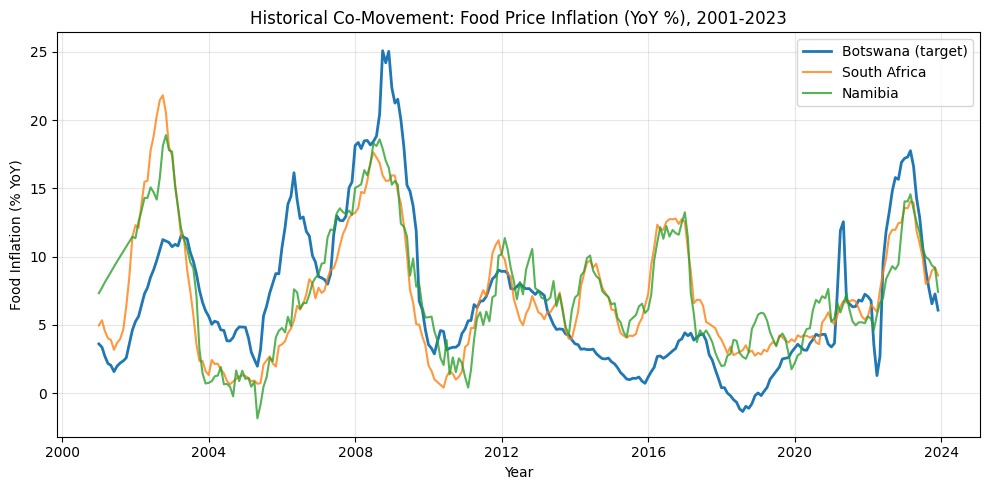

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(merged["year_month"], merged[TARGET], label="Botswana (target)", linewidth=2)
ax.plot(merged["year_month"], merged["hcp_zaf_fao_cp_23014"], label="South Africa", alpha=0.8)
ax.plot(merged["year_month"], merged["hcp_nam_fao_cp_23014"], label="Namibia", alpha=0.8)
ax.set_title("Historical Co-Movement: Food Price Inflation (YoY %), 2001-2023")
ax.set_xlabel("Year")
ax.set_ylabel("Food Inflation (% YoY)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/hcp_historical_comovement.png", dpi=150)
plt.show()


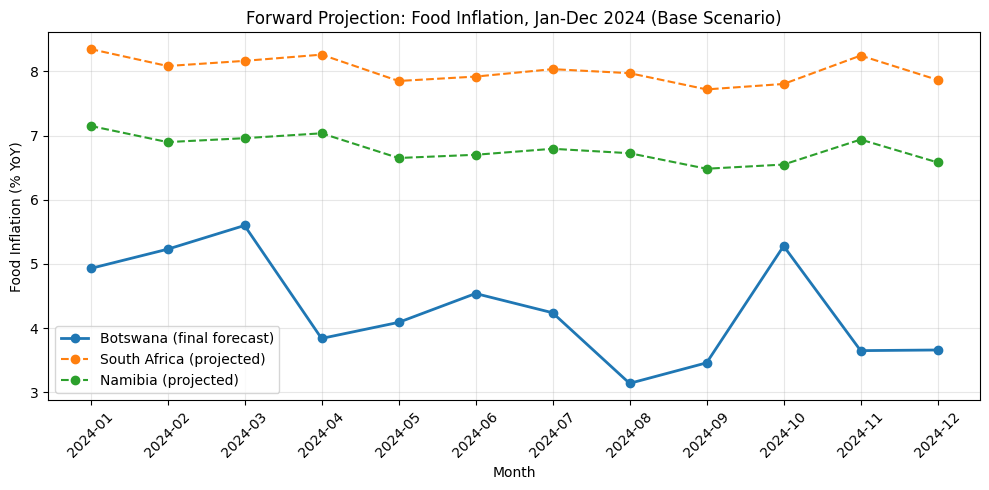

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(projection["year_month"], projection["botswana_forecast"],
        label="Botswana (final forecast)", linewidth=2, marker="o")
ax.plot(projection["year_month"], projection["south_africa_projected"],
        label="South Africa (projected)", linestyle="--", marker="o")
ax.plot(projection["year_month"], projection["namibia_projected"],
        label="Namibia (projected)", linestyle="--", marker="o")
ax.set_title("Forward Projection: Food Inflation, Jan-Dec 2024 (Base Scenario)")
ax.set_xlabel("Month")
ax.set_ylabel("Food Inflation (% YoY)")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/hcp_forward_projection.png", dpi=150)
plt.show()


## Summary for the HCP Linkage Memo

- **Statistical method:** Granger causality (bidirectional, lags 1-6, on
  first-differenced series) + OLS regression.
- **Indicators analysed:** South Africa and Namibia food-price CPI inflation
  — selected for statistically significant, economically grounded linkage
  with Botswana (SACU/CMA trade integration), consistent with Notebook 02's
  correlation-based feature selection.
- **Key numbers:** Botswana -> South Africa (lag 1, p = 0.0056), Botswana ->
  Namibia (lag 1, p = 0.0013); regression coefficients approx. 0.22-0.24
  (both p < 0.001).
- **Forward projection:** using the team's final forecast, saved to
  `data/processed/hcp_forward_projection_2024.csv`.
